<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB9_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment - *Do Androids Dream of Electric Sheep?***

-------------------------------------  

"Do Androids Dream of Electric Sheep?" – the famous title of Philip K. Dick’s novel – raises a fascinating question: if artificial intelligence could dream, what would it see?  

In this assignment, we explore a phenomenon known as **neural network dreams**, where instead of optimizing a neural network's weights, we **optimize the input itself** to achieve a desired classification outcome. Given a fully trained MNIST classification network, your goal is to manipulate its inputs so that it confidently predicts each digit from 0 to 9, starting from pure noise.  

## **Tasks Description**  

During this class we designed and trained a **MNIST classification neural network**, which takes a **batch of grayscale images** of size **$28 \times 28$** as input and outputs a probability distribution over the 10 digit classes (0–9). However, instead of using real MNIST images, you will **treat the input batch itself as a set of trainable parameters** and optimize it so that the network classifies each image as a specific digit.  

1. Your first task is to generate **a batch of 10 images**, where each image is
   classified as one of the digits **0, 1, 2, ..., 9**, starting from an initial batch of ten **random Gaussian noise images**.  

   Discuss the following question: do the generated images resemble real MNIST digits? Why or why not?  

2. Discuss, how you would approach a second task of
   generating an image that   
   bares similarity to two or more digits simultaneously. **Implement your idea to see the results.**

3. Third task: repeat the previous tasks with an additional L2 penalty on noise within the images. Experiment with adding `lambda_l2 * dreamed_input_batch.pow(2).mean()` loss term, with `lambda_l2` being the penalty cooefficient within an exponential progression, say from 0.001 to 10.0. Are the new digits recognized correctly? How does the penalty impact the digit quality? Explain.

### **Optimization Process for Task 1**  

1. Start with a **batch of 10 random Gaussian noise images** as the initial input and $(0, 1, 2, \ldots, 9)$ as the expected output batch of target digits.  
2. Define the objective: maximize the neural network's confidence for the corresponding target digit for each image in the batch.  
3. Use **gradient descent** to modify the pixels in each image, making the network classify each one as the assigned digit.  
4. Repeat until the network assigns suffieciently high confidence to each image’s target class.  

### **Implementation Details**  

- The neural network weights **must remain frozen** during optimization. You are modifying only the input images.  
- The loss function should be the **cross-entropy loss** between the predicted probabilities and the desired class labels (plus an optional weighted L2 penalty regularizing the images in task 3).




## The network

In [ ]:
import torch
import torchvision
from matplotlib import pyplot

torch.manual_seed(0)
transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(),
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = torch.nn.Sequential(

            torch.nn.Flatten(),
            torch.nn.Linear(1*28*28, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 2048),
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 10),
        )
        self.dropout = torch.nn.Dropout(0.05)

    def forward(self, x):
        x = self.mlp(x)
        x = self.dropout(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = MLP().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)

net.train()
for epoch in range(8):

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)


        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean")
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()
        optimizer.step()


## Task 1

In [ ]:
def show_dreams(dream_images):
  """
  A function to plot the dream images.
  """
  fig, axs= pyplot.subplots(2, 5)
  for n in range(10):
    i = n // 5
    j = n % 5
    ax = axs[i][j]
    ax.imshow(dream_images[n].detach().cpu().squeeze(), cmap='gray')
    ax.set_title(n)
    ax.axis('off')
  pyplot.show()


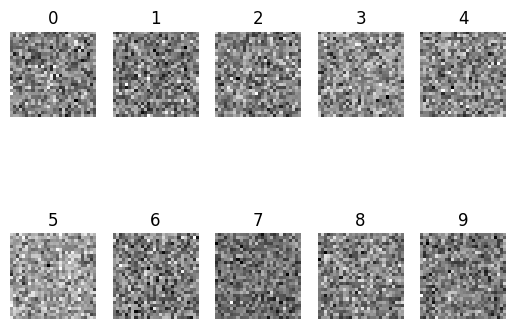

0 6.340341091156006


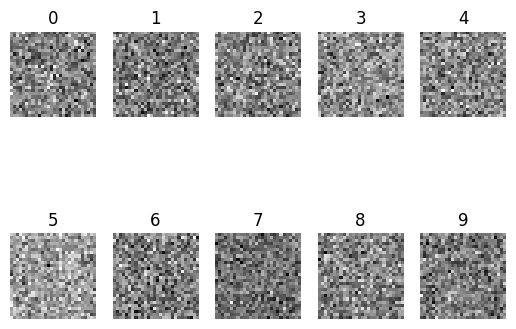

epoch 0 | loss: 6.3403 | pixel range: [-3.8312, 4.0335]
1000 0.008084970526397228


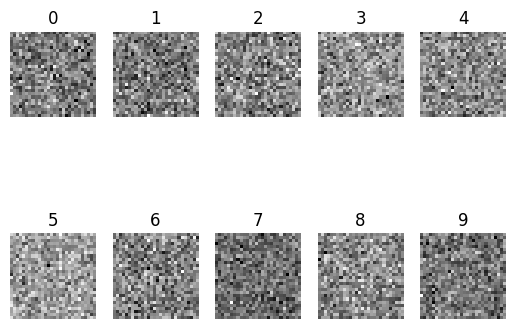

epoch 1000 | loss: 0.0081 | pixel range: [-4.0628, 4.1304]
2000 0.002125991741195321


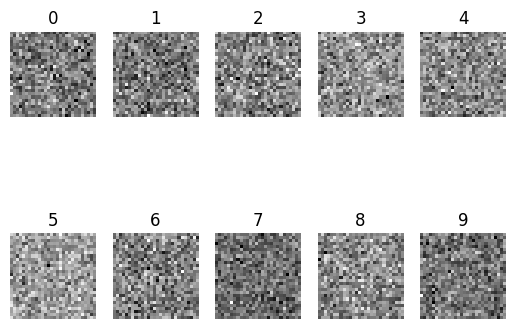

epoch 2000 | loss: 0.0021 | pixel range: [-4.0854, 4.1491]
3000 0.0008944744477048516


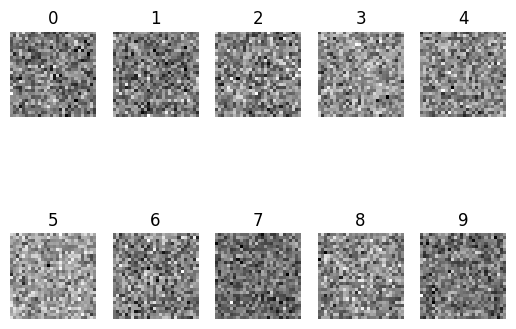

epoch 3000 | loss: 0.0009 | pixel range: [-4.0930, 4.1613]
4000 0.0004539020883385092


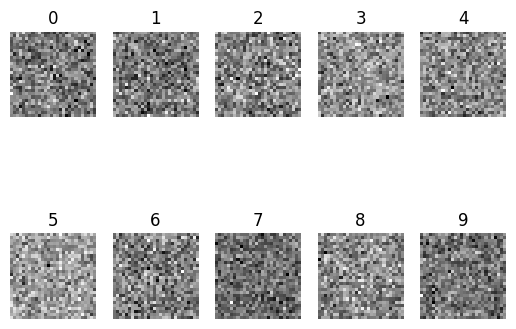

epoch 4000 | loss: 0.0005 | pixel range: [-4.1014, 4.1706]
5000 0.00025022029876708984


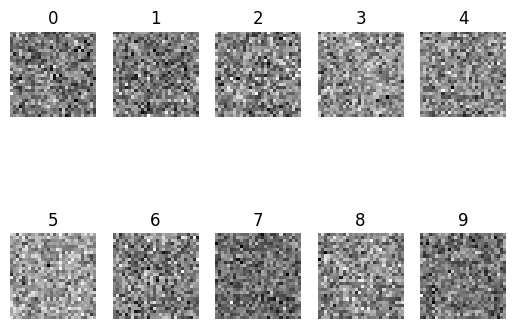

epoch 5000 | loss: 0.0003 | pixel range: [-4.1082, 4.1786]
6000 0.00014249123341869563


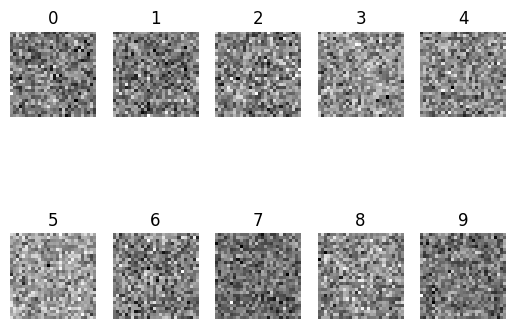

epoch 6000 | loss: 0.0001 | pixel range: [-4.1149, 4.1854]
7000 8.312072895932943e-05


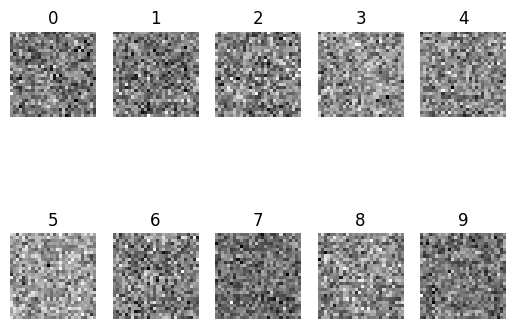

epoch 7000 | loss: 0.0001 | pixel range: [-4.1192, 4.1916]
8000 4.925591201754287e-05


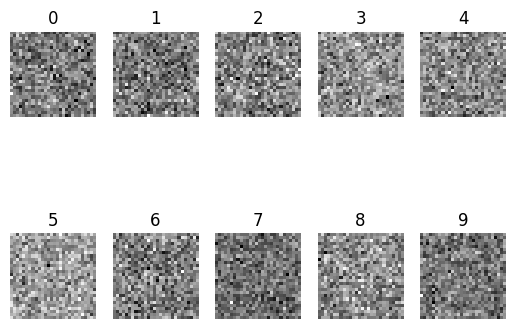

epoch 8000 | loss: 0.0000 | pixel range: [-4.1227, 4.1974]
9000 2.9289241865626536e-05


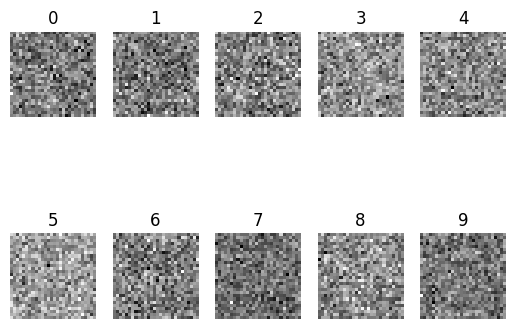

epoch 9000 | loss: 0.0000 | pixel range: [-4.1267, 4.2030]


In [ ]:
# freezing the network
net.eval()
for param in net.parameters():
    param.requires_grad = False

# generating images
dream_images = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
targets = torch.arange(10).to(device)

show_dreams(dream_images)

# training the images
optimizer = torch.optim.Adam([dream_images], 0.001)

for epoch in range(10_000):
    optimizer.zero_grad()

    outputs = net(dream_images)
    loss = torch.nn.functional.cross_entropy(outputs, targets)

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(epoch, loss.item())
        show_dreams(dream_images)
        imgs = dream_images.detach().cpu()
        print(f"epoch {epoch} | loss: {loss.item():.4f} | pixel range: [{imgs.min():.4f}, {imgs.max():.4f}]")


In [ ]:
torch.nn.functional.softmax(net(dream_images), 0).max(axis= 1).values

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0', grad_fn=<MaxBackward0>)

The loss converged and the network gained confidence in classyfying the inputs but the images do not resamble real digits. Clearly the patterns that the model learned are nothing like the human way of recognizing digits.

It is also important that the network was trained on real-digit images and it doesn't know exactly how to behave when confronted with such noisy images. When we are able to adjust every pixel out of a 28 x 28 image, we have many possibilites to find a local minimum of a loss function. It's not certain that that minimum will resamble an actual digit.

## Task 2

Generate an images that resambles two or more digits simultaneously.


The idea is to proceed analogically as in the previous task but use only one image to start with and compose loss out of two cross-entropies (one comparing to 1 and one to 7).


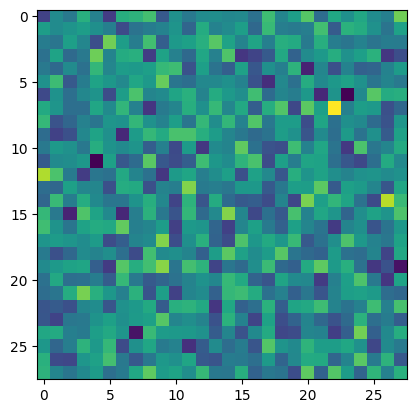

0 6.263901710510254


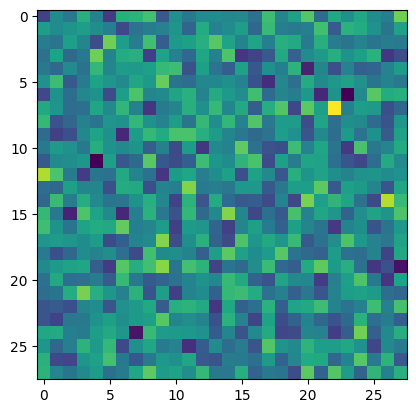

1000 1.3997421264648438


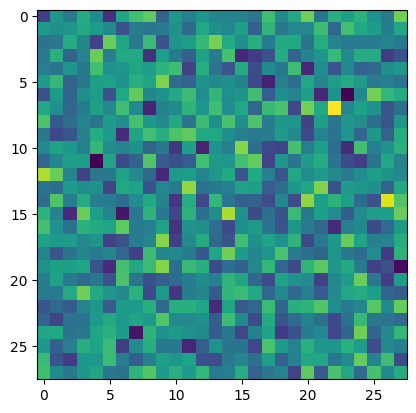

2000 1.3900550603866577


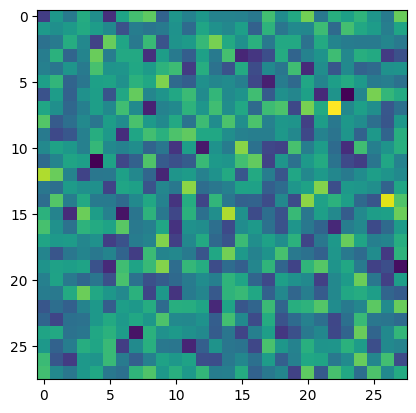

3000 1.387919545173645


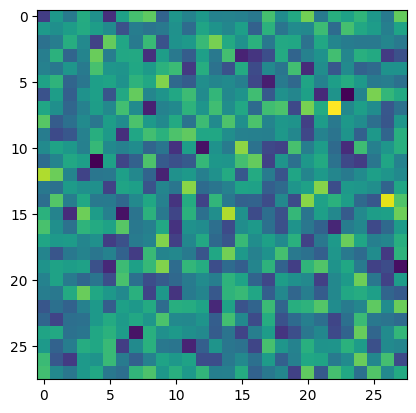

4000 1.3871091604232788


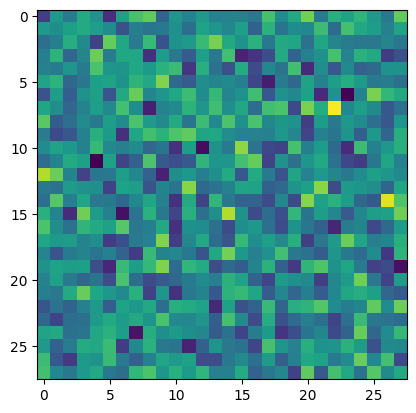

5000 1.3867378234863281


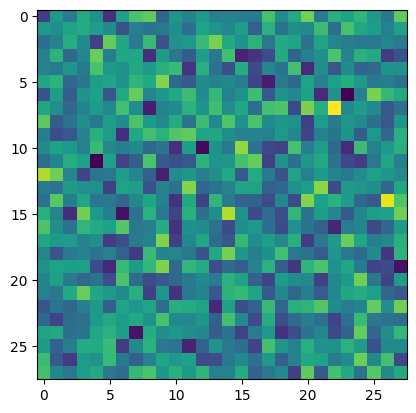

6000 1.3865482807159424


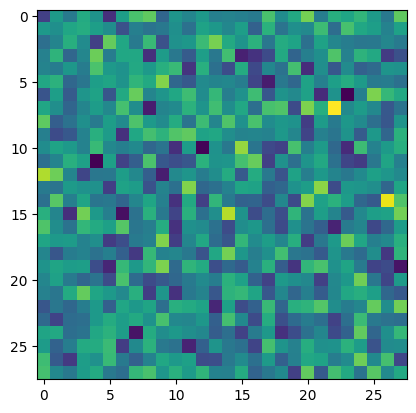

7000 1.386439323425293


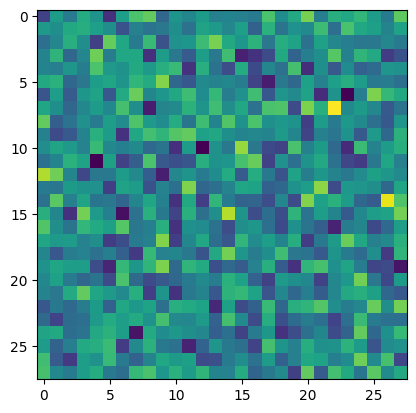

8000 1.3863797187805176


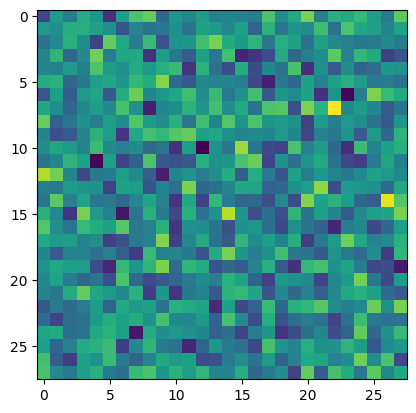

9000 1.3863455057144165


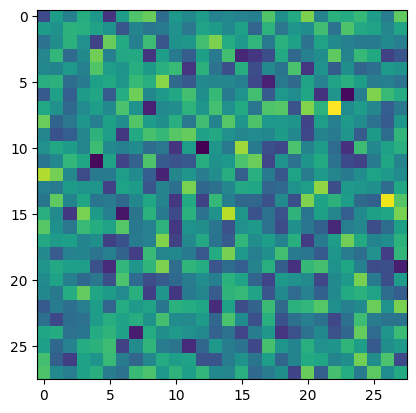

In [ ]:
net.eval()
for param in net.parameters():
    param.requires_grad = False


dream_2 = torch.randn(1, 1, 28, 28, device=device, requires_grad=True)
target_1 = torch.tensor([1]).to(device)
target_2 = torch.tensor([7]).to(device)

pyplot.imshow(dream_2.detach().cpu().squeeze())
pyplot.show()

optimizer = torch.optim.Adam([dream_2], 0.001)

for epoch in range(10_000):
    optimizer.zero_grad()

    output = net(dream_2)
    loss_1 = torch.nn.functional.cross_entropy(output, target_1)
    loss_2 = torch.nn.functional.cross_entropy(output, target_2)

    loss = loss_1 + loss_2

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(epoch, loss.item())
        pyplot.imshow(dream_2.detach().cpu().squeeze())
        pyplot.show()


The loss did not converge to 0. Using cross-entropy for this task is not efficient since it forces the net to be confident about only one label the two losses are therefore contradictory.

## Task 3

L2 penalty

lambda_l2 = 0.001


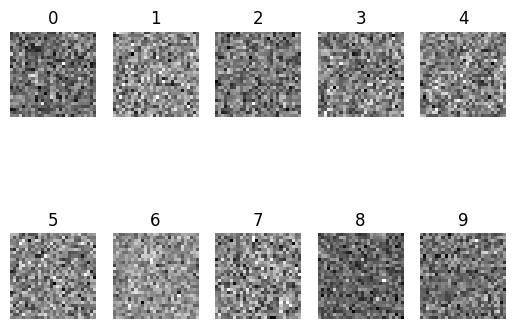

9999 0.00016879577015060931


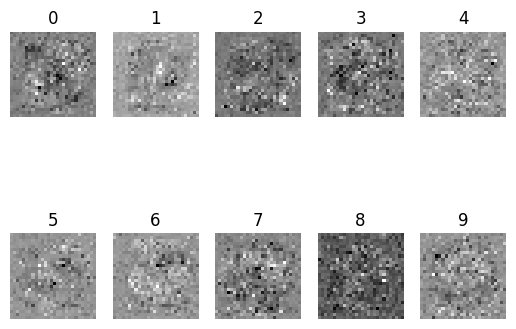

lambda_l2 = 0.001 | epoch 9999 | loss: 0.0002 | pixel range: [-2.8615, 2.8521]
lambda_l2 = 0.01


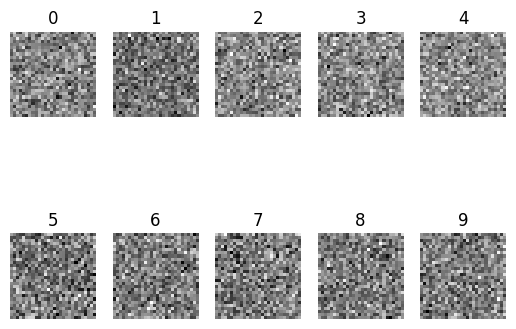

9999 0.0003091795661021024


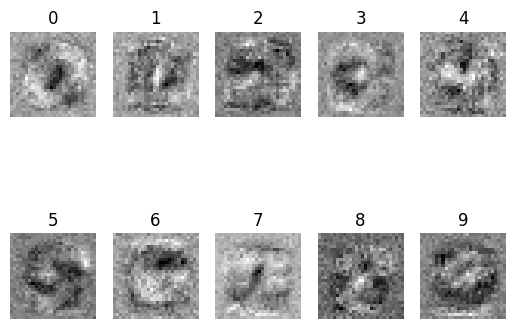

lambda_l2 = 0.01 | epoch 9999 | loss: 0.0003 | pixel range: [-0.7835, 0.8663]
lambda_l2 = 0.1


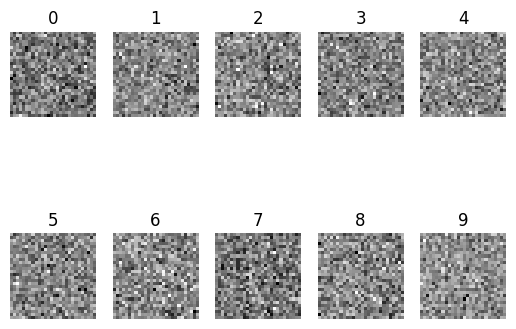

9999 0.0021374919451773167


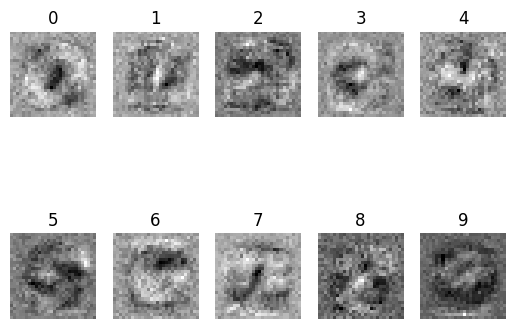

lambda_l2 = 0.1 | epoch 9999 | loss: 0.0021 | pixel range: [-0.6260, 0.7217]
lambda_l2 = 1


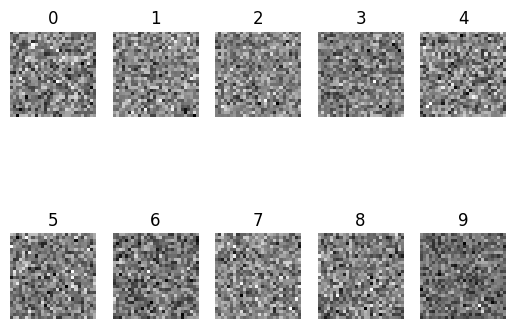

9999 0.013838604092597961


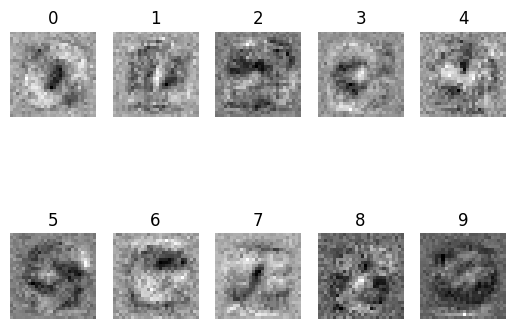

lambda_l2 = 1 | epoch 9999 | loss: 0.0138 | pixel range: [-0.5104, 0.5847]
lambda_l2 = 10


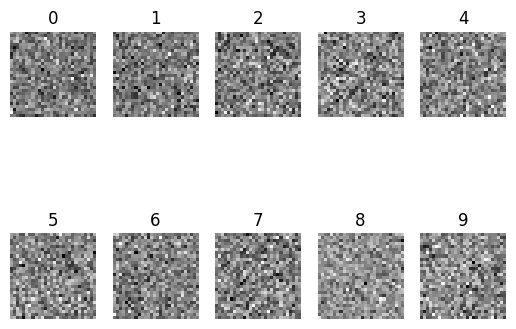

9999 0.08137787133455276


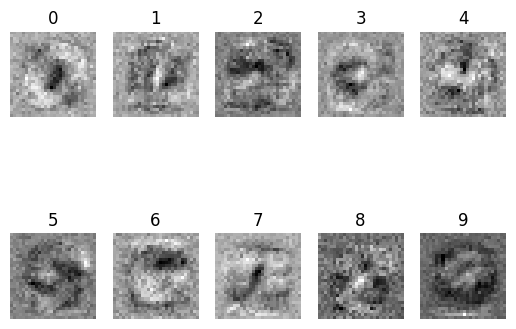

lambda_l2 = 10 | epoch 9999 | loss: 0.0814 | pixel range: [-0.3785, 0.4092]


In [ ]:
for lambda_l2 in [0.001, 0.01, 0.1, 1, 10]:
  print(f"lambda_l2 = {lambda_l2}")
  dream_images = torch.randn(10, 1, 28, 28, device=device, requires_grad=True)
  targets = torch.arange(10).to(device)
  show_dreams(dream_images)
  optimizer = torch.optim.Adam([dream_images], 0.01)

  for epoch in range(10_000):
      optimizer.zero_grad()

      outputs = net(dream_images)
      ce_loss = torch.nn.functional.cross_entropy(outputs, targets)
      l2_loss = lambda_l2 * dream_images.pow(2).mean()

      loss  = ce_loss + l2_loss
      loss.backward()
      optimizer.step()

      if epoch == 9999:
          print(epoch, loss.item())
          show_dreams(dream_images)
          imgs = dream_images.detach().cpu()
          print(f"lambda_l2 = {lambda_l2} | epoch {epoch} | loss: {loss.item():.4f} | pixel range: [{imgs.min():.4f}, {imgs.max():.4f}]")


With the L2 penalty, more interpretable shapes emerge. Especially for large $\lambda$ the images need to posses features that the network has learned without much flexibility. When the images are less noisy, the outputs start to resamble real digits (or at least some of their patterns).



lambda_l2 = 0.001


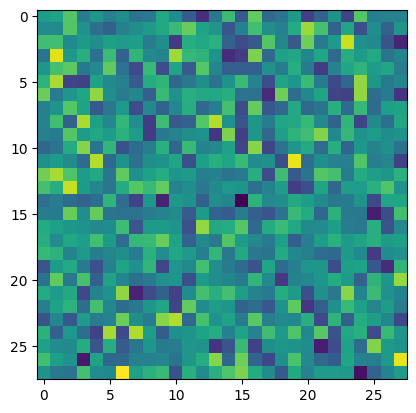

9999 1.386324167251587


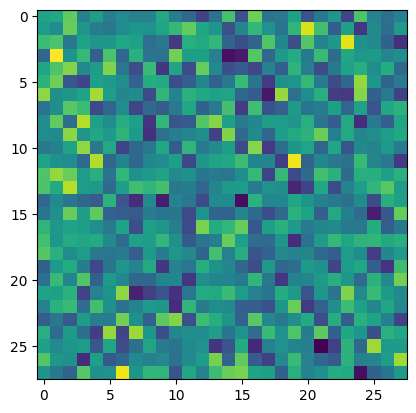

lambda_l2 = 0.01


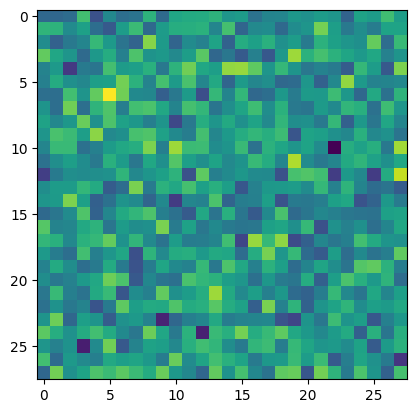

9999 1.3864177465438843


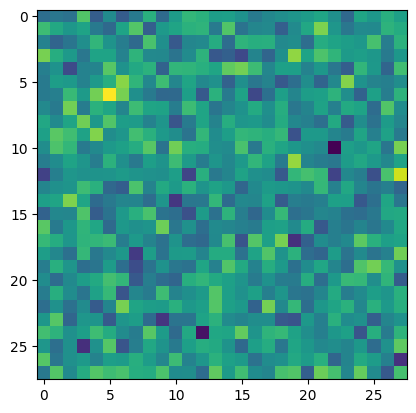

lambda_l2 = 0.1


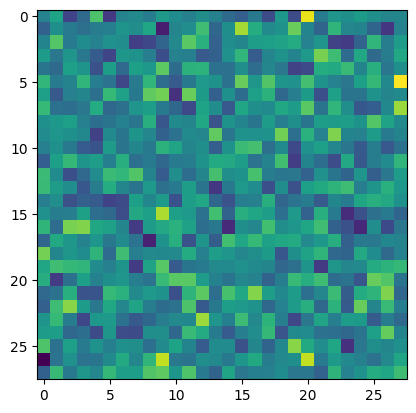

9999 1.386947751045227


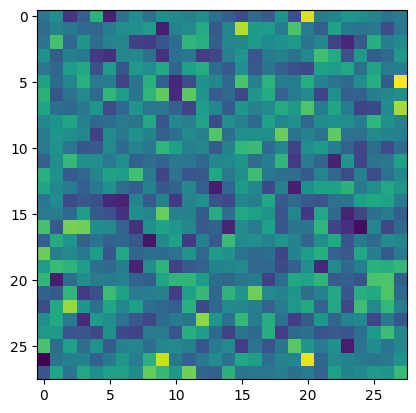

lambda_l2 = 1


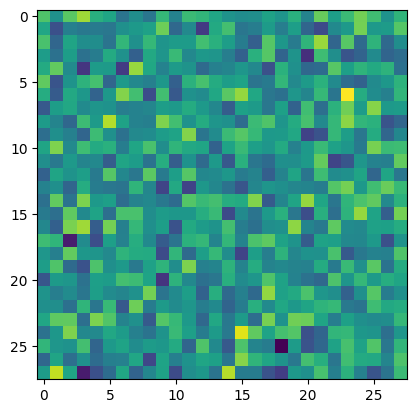

9999 1.3923553228378296


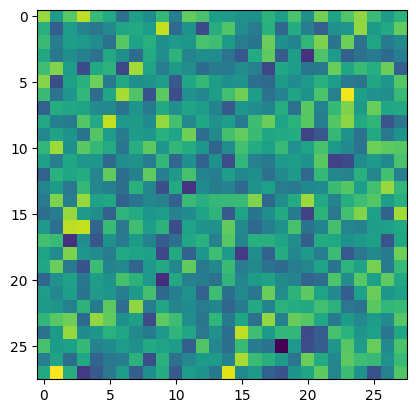

lambda_l2 = 10


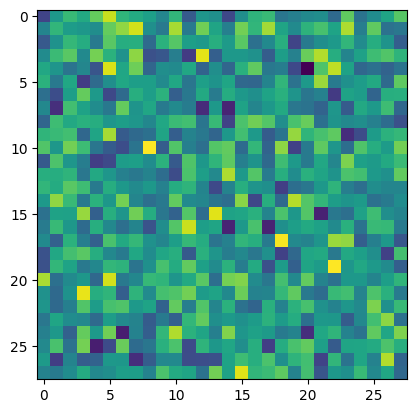

9999 1.4465899467468262


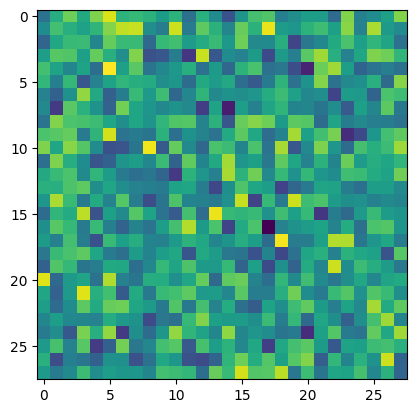

In [ ]:
for lambda_l2 in [0.001, 0.01, 0.1, 1, 10]:
  print(f"lambda_l2 = {lambda_l2}")
  dream_2 = torch.randn(1, 1, 28, 28, device=device, requires_grad=True)
  target_1 = torch.tensor([1]).to(device)
  target_2 = torch.tensor([7]).to(device)

  pyplot.imshow(dream_2.detach().cpu().squeeze())
  pyplot.show()
  optimizer = torch.optim.Adam([dream_2], 0.001)

  for epoch in range(10_000):
      optimizer.zero_grad()

      output = net(dream_2)
      l2_loss = lambda_l2 * dream_images.pow(2).mean()
      loss_1 = torch.nn.functional.cross_entropy(output, target_1)
      loss_2 = torch.nn.functional.cross_entropy(output, target_2)

      loss = loss_1 + loss_2 + l2_loss
      loss.backward()
      optimizer.step()

      if epoch == 9999:
        print(epoch, loss.item())
        pyplot.imshow(dream_2.detach().cpu().squeeze())
        pyplot.show()

The L2-penalty didn't improve the results. It seems like the issue with constraining ourselves to cross-entropy loss is crucial in this case.